In [ ]:
from btree import BTree, serialize, deserialize
import random

ORDER = 10
bt = BTree[str](ORDER)
insert_log = []
for i in range(1000):
    # Insert random numbers into the B-tree
    to_insert = "".join(random.choices("abcdefghijklmnopqrstuvwxyz", k=5))
    insert_log.append(to_insert)
    bt.insert(to_insert)

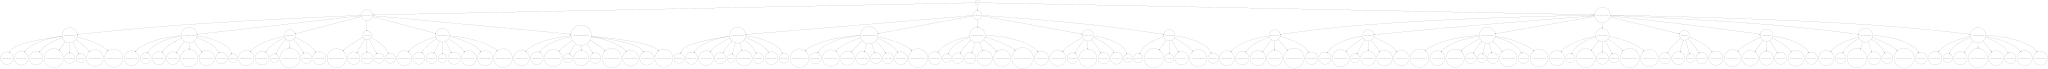

In [2]:
from graphviz import Digraph
from IPython.display import display, SVG


def visualize_btree(btree):
    dot = Digraph()
    # Set some global node defaults:
    dot.attr("node", shape="circle", fontsize="10")  # smaller font

    def add_nodes_edges(node, parent=None):
        if node is None:
            return

        node_id = str(id(node))
        # Format label as just the comma-separated keys
        label = ", ".join(str(k) for k in node.keys)
        dot.node(node_id, label=label)

        if parent is not None:
            dot.edge(str(id(parent)), node_id)

        for child in node.children:
            add_nodes_edges(child, node)

    add_nodes_edges(btree.root)
    return dot


# Usage:
dot = visualize_btree(bt)
dot.format = "svg"
display(SVG(dot.pipe()))

In [25]:
#  fuzz testing
from validation import validate_btree, equal_trees


def one_test():
    bt = BTree[str](ORDER)
    insert_log = []
    for i in range(1000):
        to_insert = "".join(random.choices("abcdefghijklmnopqrstuvwxyz", k=5))
        insert_log.append(to_insert)
        bt.insert(to_insert)
    validate_btree(bt, insert_log)
    bt2 = deserialize(serialize(bt))
    assert equal_trees(
        bt.root, bt2.root
    ), "Deserialized tree does not match original tree"


for _ in range(100):
    one_test()

✓ All inserted values exist in the B-tree.
✓ All non-inserted values correctly not found in the B-tree.
✓ All nodes have valid number of keys.
✓ In-order traversal matches sorted insert set.
✓ All inserted values exist in the B-tree.
✓ All non-inserted values correctly not found in the B-tree.
✓ All nodes have valid number of keys.
✓ In-order traversal matches sorted insert set.
✓ All inserted values exist in the B-tree.
✓ All non-inserted values correctly not found in the B-tree.
✓ All nodes have valid number of keys.
✓ In-order traversal matches sorted insert set.
✓ All inserted values exist in the B-tree.
✓ All non-inserted values correctly not found in the B-tree.
✓ All nodes have valid number of keys.
✓ In-order traversal matches sorted insert set.
✓ All inserted values exist in the B-tree.
✓ All non-inserted values correctly not found in the B-tree.
✓ All nodes have valid number of keys.
✓ In-order traversal matches sorted insert set.
✓ All inserted values exist in the B-tree.
✓ 